In [5]:
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
df = pd.read_csv(r"C:\Crime_Incidents_in_2024.csv")  # Dosyanın tam yolunu kullan
df.head()

,X,Y,CCN,REPORT_DAT,SHIFT,METHOD,OFFENSE,BLOCK,XBLOCK,YBLOCK,...,BLOCK_GROUP,CENSUS_TRACT,VOTING_PRECINCT,LATITUDE,LONGITUDE,BID,START_DATE,END_DATE,OBJECTID,OCTO_RECORD_ID
0,399622.2700,134352.62,24093246,2024/06/19 14:52:56+00,DAY,OTHERS,THEFT/OTHER,1100 - 1199 BLOCK OF NEW JERSEY AVENUE SE,399622.270000,134352.620000,...,007203 1,7203.0,Precinct 131,38.877004,-77.004353,CAPITOL RIVERFRONT,2024/06/19 14:50:00+00,2024/06/19 14:52:00+00,679448603,NaN
1,398579.1351,134828.40,24131497,2024/08/27 01:13:37+00,EVENING,OTHERS,THEFT F/AUTO,300 - 399 BLOCK OF G STREET SW,398579.135069,134828.399995,...,010500 2,10500.0,Precinct 128,38.881289,-77.016376,SOUTHWEST,2024/08/26 18:51:00+00,2024/08/26 20:14:00+00,679448604,NaN
2,396836.0500,139850.46,24120734,2024/08/07 07:10:35+00,MIDNIGHT,OTHERS,THEFT/OTHER,16TH STREET NW AND COLUMBIA ROAD NW,396836.050011,139850.459999,...,003901 1,3901.0,Precinct 39,38.926525,-77.036488,NaN,2024/08/04 01:00:00+00,2024/08/04 01:30:00+00,679449098,NaN
3,398010.0800,138818.94,24168124,2024/10/30 03:40:30+00,MIDNIGHT,OTHERS,THEFT/OTHER,2000 - 2099 BLOCK OF 8TH STREET NW,398010.080000,138818.940000,...,003500 3,3500.0,Precinct 37,38.917236,-77.022946,NaN,2024/10/29 04:00:00+00,2024/10/29 20:00:00+00,679449103,NaN
4,397424.6800,141258.25,24172277,2024/11/05 23:15:06+00,EVENING,OTHERS,MOTOR VEHICLE THEFT,3900 - 3999 BLOCK OF 13TH STREET NW,397424.680000,141258.250000,...,002503 1,2503.0,Precinct 47,38.939209,-77.029705,NaN,2024/11/05 22:22:00+00,NaN,679449104,NaN


In [7]:

df['REPORT_DAT'] = pd.to_datetime(df['REPORT_DAT'])


df['REPORT_YEAR'] = df['REPORT_DAT'].dt.year
df['REPORT_MONTH'] = df['REPORT_DAT'].dt.month
df['REPORT_DAY'] = df['REPORT_DAT'].dt.day


print(df[['REPORT_DAT', 'REPORT_YEAR', 'REPORT_MONTH', 'REPORT_DAY']].head())


                 REPORT_DAT  REPORT_YEAR  REPORT_MONTH  REPORT_DAY
0 2024-06-19 14:52:56+00:00         2024             6          19
1 2024-08-27 01:13:37+00:00         2024             8          27
2 2024-08-07 07:10:35+00:00         2024             8           7
3 2024-10-30 03:40:30+00:00         2024            10          30
4 2024-11-05 23:15:06+00:00         2024            11           5


In [11]:
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(strategy="mean")
X_filled = imputer.fit_transform(X)



In [48]:

df_numerical = df.select_dtypes(include=['number'])

df[df_numerical.columns] = df_numerical.fillna(df_numerical.median())

df_categorical = df.select_dtypes(include=['object'])

df[df_categorical.columns] = df_categorical.fillna(df_categorical.mode().iloc[0])

print(df.isnull().sum())



X                           0
Y                           0
CCN                         0
REPORT_DAT                  0
SHIFT                       0
METHOD                      0
OFFENSE                     0
BLOCK                       0
XBLOCK                      0
YBLOCK                      0
WARD                        0
ANC                         0
DISTRICT                    0
PSA                         0
NEIGHBORHOOD_CLUSTER        0
BLOCK_GROUP                 0
CENSUS_TRACT                0
VOTING_PRECINCT             0
LATITUDE                    0
LONGITUDE                   0
BID                         0
START_DATE                  0
END_DATE                    0
OBJECTID                    0
OCTO_RECORD_ID          29294
dtype: int64


In [54]:
print(df.columns)

Index(['X', 'Y', 'CCN', 'REPORT_DAT', 'SHIFT', 'METHOD', 'OFFENSE', 'BLOCK',
       'XBLOCK', 'YBLOCK', 'WARD', 'ANC', 'DISTRICT', 'PSA',
       'NEIGHBORHOOD_CLUSTER', 'BLOCK_GROUP', 'CENSUS_TRACT',
       'VOTING_PRECINCT', 'LATITUDE', 'LONGITUDE', 'BID', 'START_DATE',
       'END_DATE', 'OBJECTID', 'OCTO_RECORD_ID'],
      dtype='object')


In [56]:

df['REPORT_DAT'] = pd.to_datetime(df['REPORT_DAT'], errors='coerce')


df['REPORT_YEAR'] = df['REPORT_DAT'].dt.year
df['REPORT_MONTH'] = df['REPORT_DAT'].dt.month
df['REPORT_DAY'] = df['REPORT_DAT'].dt.day


print(df[['REPORT_YEAR', 'REPORT_MONTH', 'REPORT_DAY']].head())


   REPORT_YEAR  REPORT_MONTH  REPORT_DAY
0         2024             6          19
1         2024             8          27
2         2024             8           7
3         2024            10          30
4         2024            11           5


In [58]:
print(df.columns)


Index(['X', 'Y', 'CCN', 'REPORT_DAT', 'SHIFT', 'METHOD', 'OFFENSE', 'BLOCK',
       'XBLOCK', 'YBLOCK', 'WARD', 'ANC', 'DISTRICT', 'PSA',
       'NEIGHBORHOOD_CLUSTER', 'BLOCK_GROUP', 'CENSUS_TRACT',
       'VOTING_PRECINCT', 'LATITUDE', 'LONGITUDE', 'BID', 'START_DATE',
       'END_DATE', 'OBJECTID', 'OCTO_RECORD_ID', 'REPORT_YEAR', 'REPORT_MONTH',
       'REPORT_DAY'],
      dtype='object')


In [66]:

df['REPORT_DAT'] = pd.to_datetime(df['REPORT_DAT'], errors='coerce')


df['REPORT_YEAR'] = df['REPORT_DAT'].dt.year
df['REPORT_MONTH'] = df['REPORT_DAT'].dt.month
df['REPORT_DAY'] = df['REPORT_DAT'].dt.day

print(df.columns)


Index(['X', 'Y', 'CCN', 'REPORT_DAT', 'SHIFT', 'METHOD', 'OFFENSE', 'BLOCK',
       'XBLOCK', 'YBLOCK', 'WARD', 'ANC', 'DISTRICT', 'PSA',
       'NEIGHBORHOOD_CLUSTER', 'BLOCK_GROUP', 'CENSUS_TRACT',
       'VOTING_PRECINCT', 'LATITUDE', 'LONGITUDE', 'BID', 'START_DATE',
       'END_DATE', 'OBJECTID', 'OCTO_RECORD_ID', 'REPORT_YEAR', 'REPORT_MONTH',
       'REPORT_DAY'],
      dtype='object')


In [68]:

X = df[['X', 'Y', 'SHIFT', 'METHOD', 'WARD', 'DISTRICT', 'PSA', 
        'NEIGHBORHOOD_CLUSTER', 'BLOCK_GROUP', 'CENSUS_TRACT', 
        'LATITUDE', 'LONGITUDE', 'REPORT_YEAR', 'REPORT_MONTH', 'REPORT_DAY']]
y = df['OFFENSE']


In [70]:

X = pd.get_dummies(X)


In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [80]:
from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()


y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


In [84]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),  
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}


In [88]:
from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train_scaled, y_train_encoded)  
    
    print(f"Predicting with {model_name}...")
    y_pred = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test_encoded, y_pred)  
    accuracies[model_name] = accuracy * 100


print("\nModel Accuracy Comparison:")
for model_name, accuracy in accuracies.items():
    print(f"{model_name} Accuracy: {accuracy:.2f}%")


Training Logistic Regression...
Predicting with Logistic Regression...
Training Random Forest...
Predicting with Random Forest...
Training XGBoost...
Predicting with XGBoost...
Training K-Nearest Neighbors...
Predicting with K-Nearest Neighbors...
Training SVM...
Predicting with SVM...

Model Accuracy Comparison:
Logistic Regression Accuracy: 51.77%
Random Forest Accuracy: 52.57%
XGBoost Accuracy: 54.24%
K-Nearest Neighbors Accuracy: 47.74%
SVM Accuracy: 51.85%


In [92]:
pip install matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


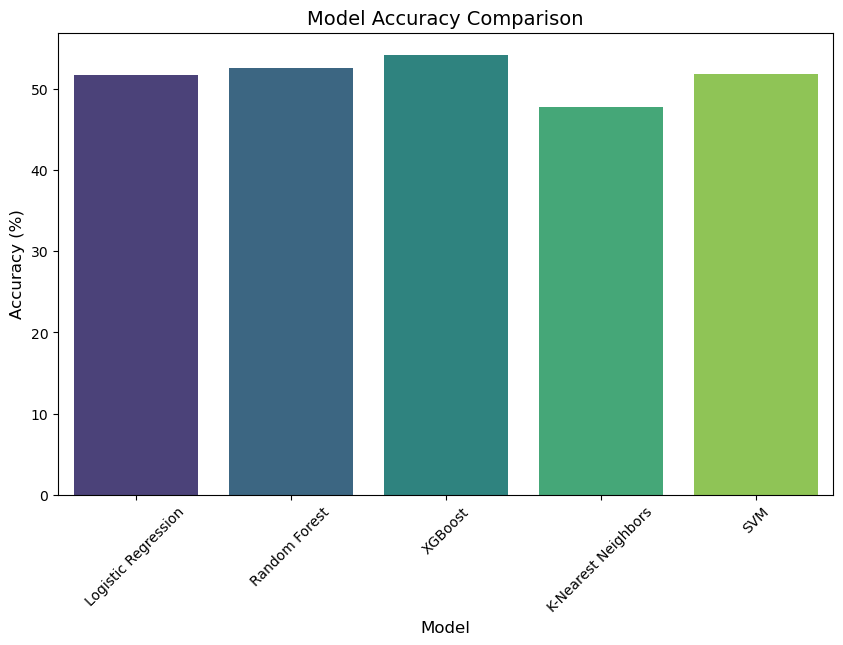

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Model Accuracy Comparison grafiği için
model_names = list(accuracies.keys())
accuracy_values = list(accuracies.values())

# Grafik oluşturma
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=accuracy_values, hue=model_names, palette='viridis')

# Başlık ve etiketler
plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)

# Grafik gösterimi
plt.xticks(rotation=45)  # X eksenindeki model isimlerini döndür
plt.show()






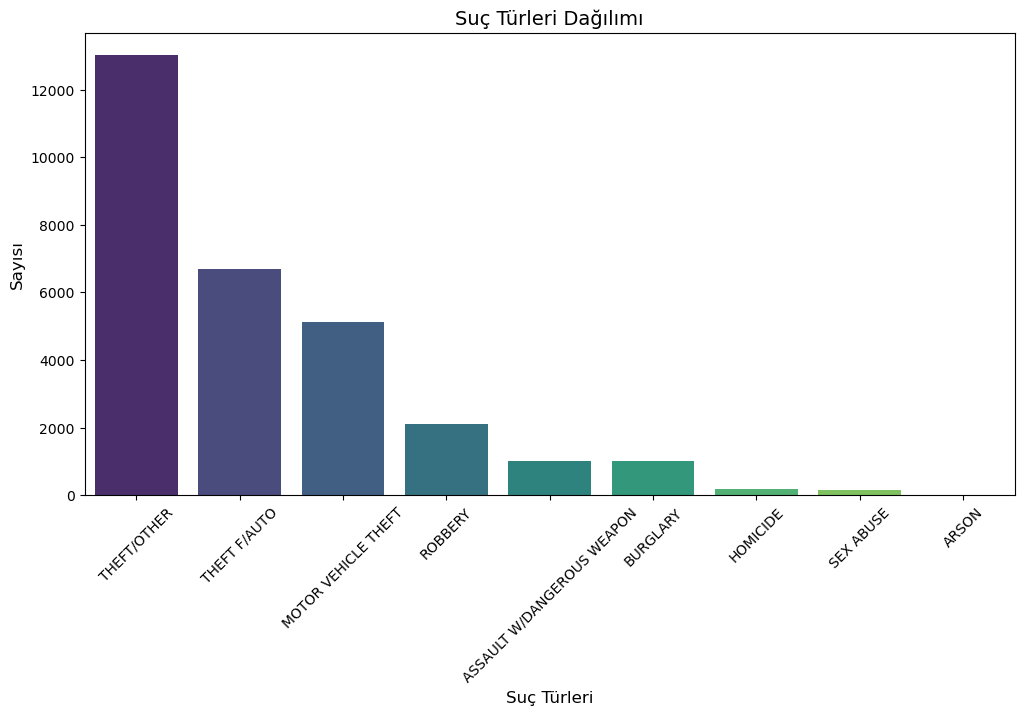

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

# Suç türlerinin sayısını hesaplayalım
offense_counts = df['OFFENSE'].value_counts()

# Grafik oluşturma
plt.figure(figsize=(12, 6))
sns.barplot(x=offense_counts.index, y=offense_counts.values, hue=offense_counts.index, palette='viridis')

# Başlık ve etiketler
plt.title("Suç Türleri Dağılımı", fontsize=14)
plt.xlabel("Suç Türleri", fontsize=12)
plt.ylabel("Sayısı", fontsize=12)

# Grafik gösterimi
plt.xticks(rotation=45) 
plt.show()



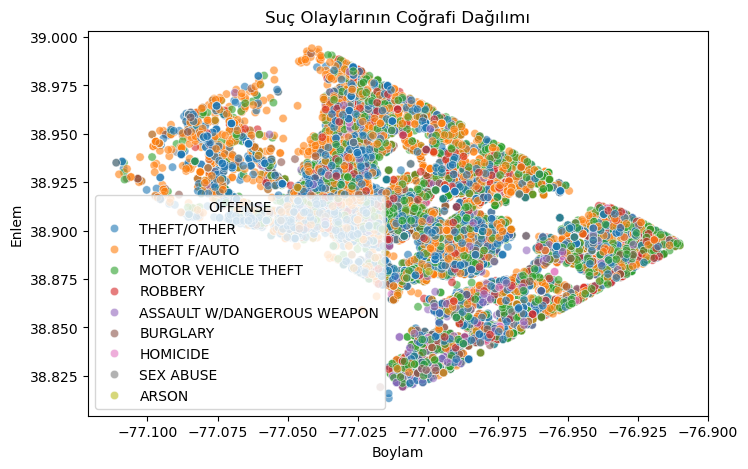

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="LONGITUDE", y="LATITUDE", hue="OFFENSE", alpha=0.6)
plt.title("Suç Olaylarının Coğrafi Dağılımı")
plt.xlabel("Boylam")
plt.ylabel("Enlem")
plt.show()



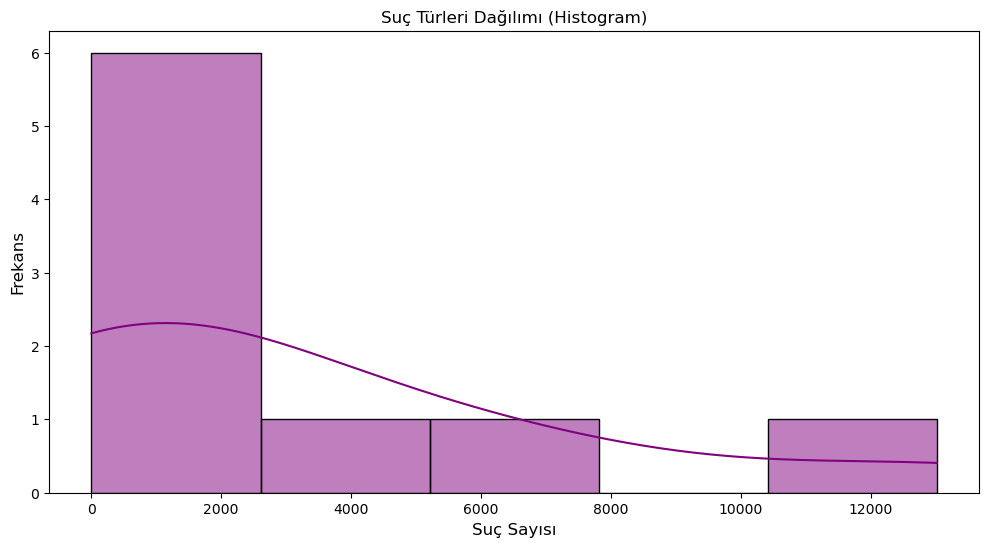

In [116]:
import seaborn as sns

# Suç türlerinin sayısını hesaplayalım
offense_counts = df['OFFENSE'].value_counts()

# Histogram oluşturma
plt.figure(figsize=(12, 6))
sns.histplot(offense_counts.values, kde=True, color='purple')
plt.title("Suç Türleri Dağılımı (Histogram)")
plt.xlabel("Suç Sayısı", fontsize=12)
plt.ylabel("Frekans", fontsize=12)
plt.show()


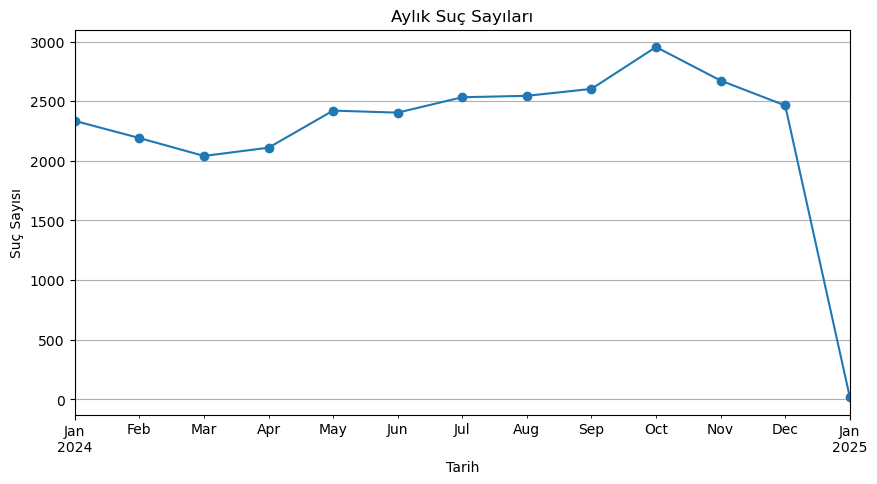

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Tarih sütununu datetime formatına çevirme
df["REPORT_DAT"] = pd.to_datetime(df["REPORT_DAT"])

# Tarihe göre gruplama ve aylık suç sayılarını çizme
df.set_index("REPORT_DAT").resample("ME")["OFFENSE"].count().plot(marker="o", linestyle="-", figsize=(10, 5))

plt.title("Aylık Suç Sayıları")
plt.xlabel("Tarih")
plt.ylabel("Suç Sayısı")
plt.grid(True)
plt.show()




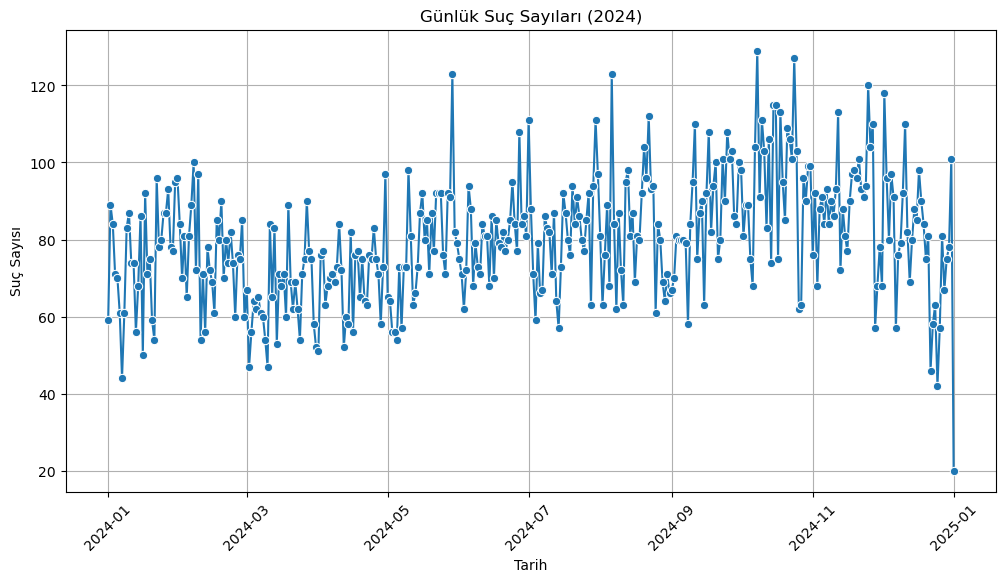

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Tarih sütununu datetime formatına çevir
df["REPORT_DAT"] = pd.to_datetime(df["REPORT_DAT"])

# Günlük suç sayısını hesapla
crime_counts = df["REPORT_DAT"].dt.date.value_counts().sort_index()

# Çizgi grafiği oluştur
plt.figure(figsize=(12, 6))
sns.lineplot(x=crime_counts.index, y=crime_counts.values, marker="o", linestyle="-")
plt.xlabel("Tarih")
plt.ylabel("Suç Sayısı")
plt.title("Günlük Suç Sayıları (2024)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



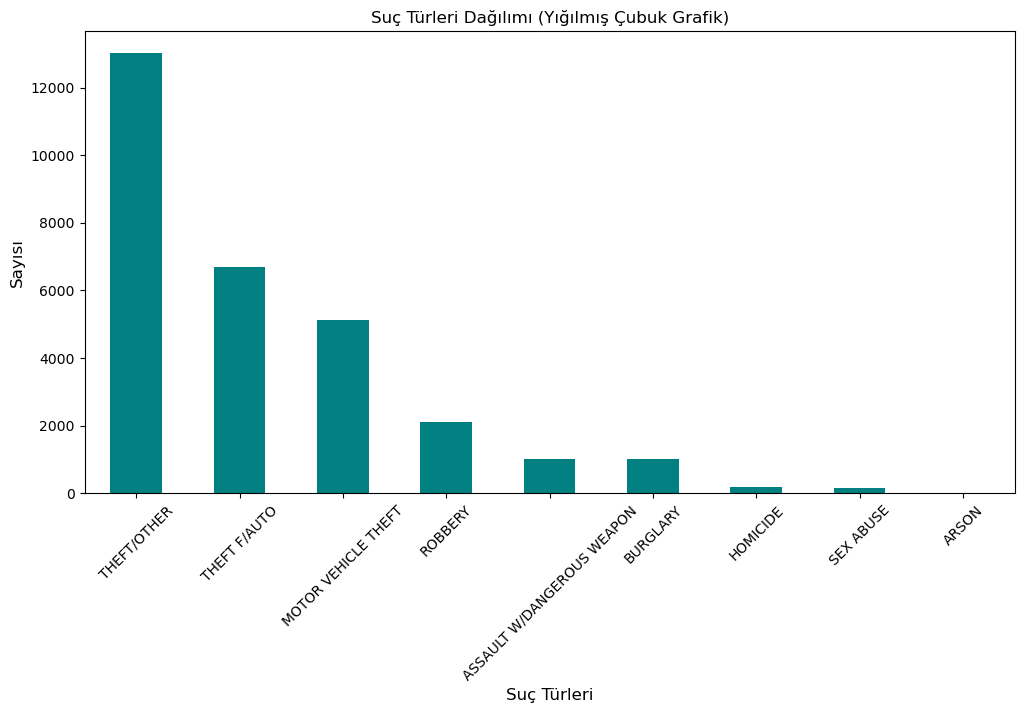

In [110]:
# Suç türlerinin sayısını hesaplayalım
offense_counts = df['OFFENSE'].value_counts()

# Yığılmış çubuk grafik
plt.figure(figsize=(12, 6))
offense_counts.plot(kind='bar', stacked=False, color='teal')
plt.title("Suç Türleri Dağılımı (Yığılmış Çubuk Grafik)")
plt.xlabel("Suç Türleri", fontsize=12)
plt.ylabel("Sayısı", fontsize=12)
plt.xticks(rotation=45)
plt.show()


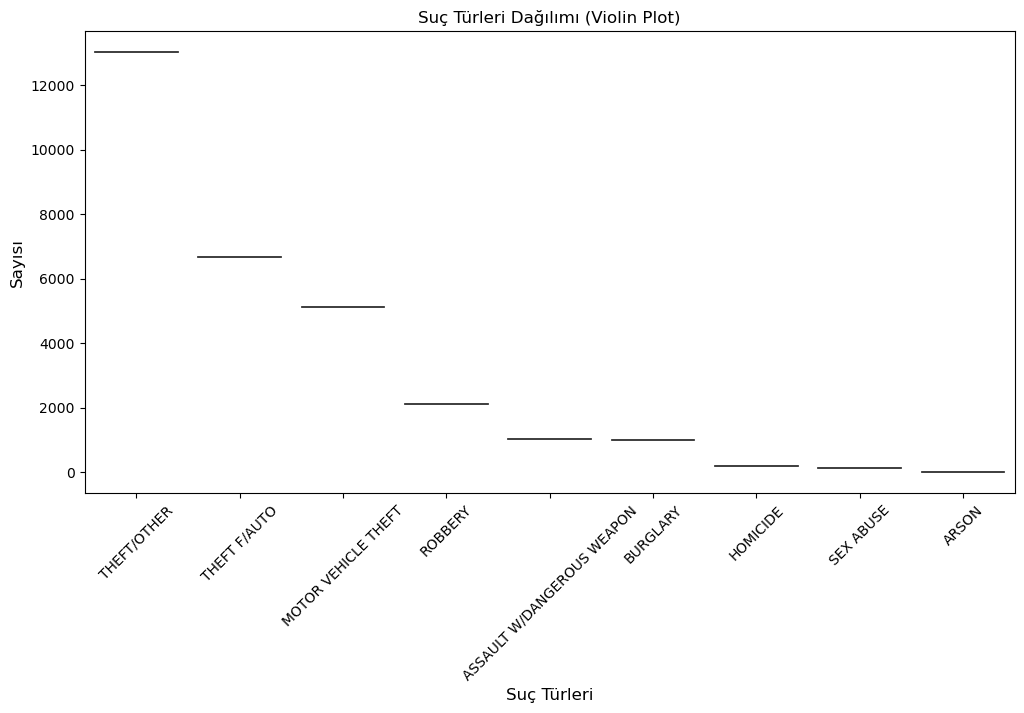

In [165]:
import seaborn as sns
import matplotlib.pyplot as plt

# Suç türlerinin sayısını hesaplayalım
offense_counts = df['OFFENSE'].value_counts()

# Violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x=offense_counts.index, y=offense_counts.values, color='purple')  # 'viridis' yerine sabit bir renk kullanabilirsiniz
plt.title("Suç Türleri Dağılımı (Violin Plot)")
plt.xlabel("Suç Türleri", fontsize=12)
plt.ylabel("Sayısı", fontsize=12)
plt.xticks(rotation=45)
plt.show()



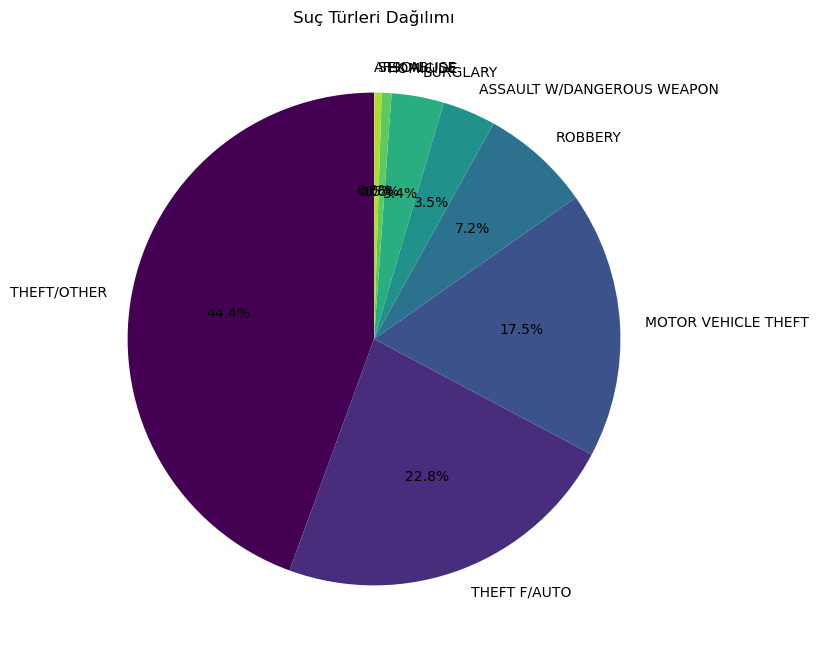

In [118]:
import matplotlib.pyplot as plt

# Suç türlerinin sayısını hesaplayalım
offense_counts = df['OFFENSE'].value_counts()

# Pasta grafiği oluşturma
plt.figure(figsize=(8, 8))
offense_counts.plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis', legend=False)
plt.title("Suç Türleri Dağılımı")
plt.ylabel('')  # Y eksenini gizle
plt.show()


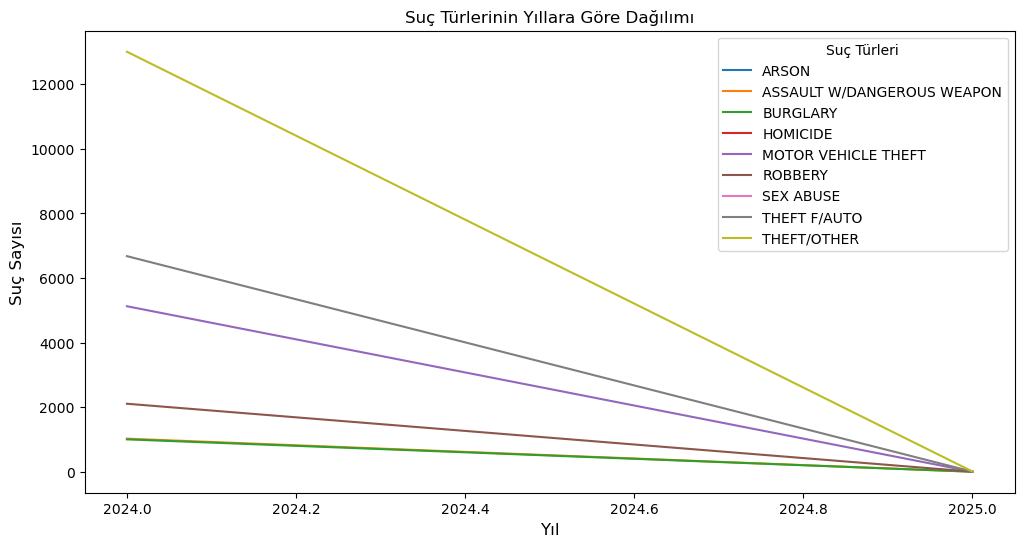

In [120]:
# Suç türlerinin yıllara göre dağılımını çizgi grafiği ile gösterme
df['REPORT_YEAR'] = pd.to_datetime(df['REPORT_DAT']).dt.year
yearly_offense_counts = df.groupby('REPORT_YEAR')['OFFENSE'].value_counts()

plt.figure(figsize=(12, 6))
for offense in yearly_offense_counts.index.levels[1]:
    offense_data = yearly_offense_counts.xs(offense, level=1)
    plt.plot(offense_data.index, offense_data.values, label=offense)

plt.title("Suç Türlerinin Yıllara Göre Dağılımı")
plt.xlabel("Yıl", fontsize=12)
plt.ylabel("Suç Sayısı", fontsize=12)
plt.legend(title="Suç Türleri")
plt.show()


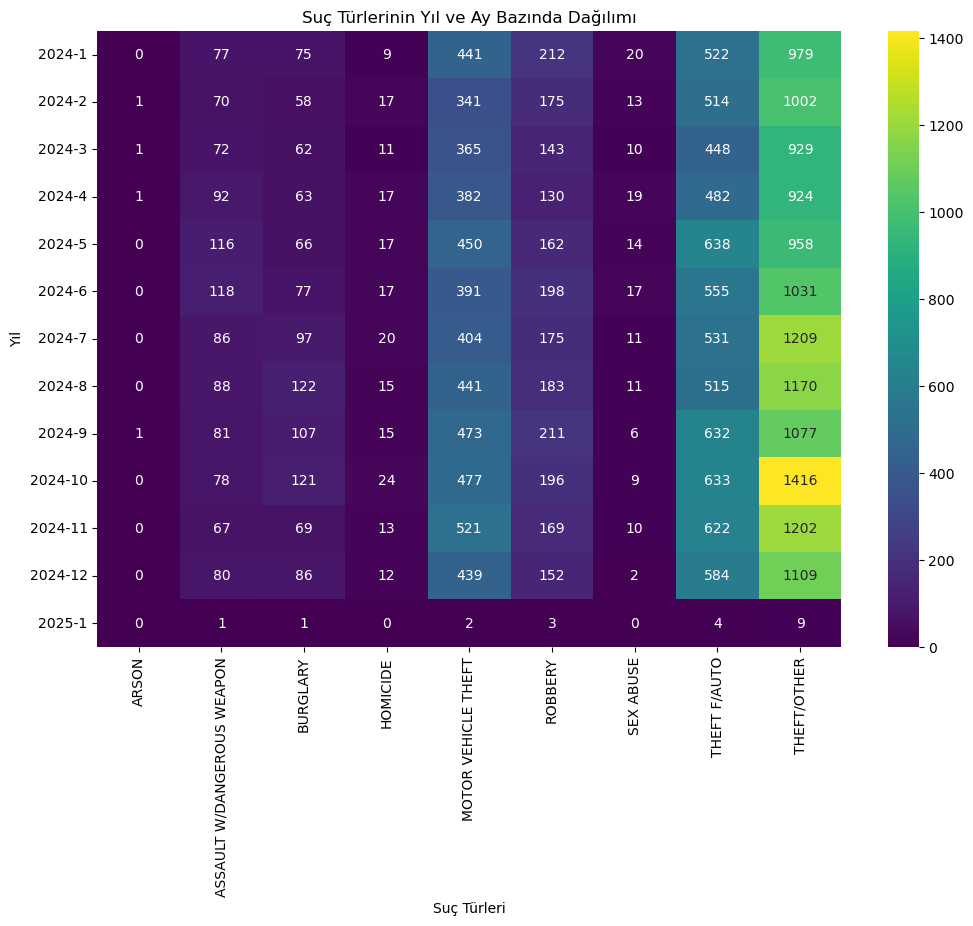

In [122]:
import seaborn as sns

# Suç türlerinin yıl ve ay bazında dağılımını heatmap ile gösterme
df['REPORT_MONTH'] = pd.to_datetime(df['REPORT_DAT']).dt.month
df_heatmap = df.groupby(['REPORT_YEAR', 'REPORT_MONTH', 'OFFENSE']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(df_heatmap, annot=True, cmap="viridis", fmt="d")
plt.title("Suç Türlerinin Yıl ve Ay Bazında Dağılımı")
plt.xlabel("Suç Türleri")
plt.ylabel("Yıl")
plt.show()


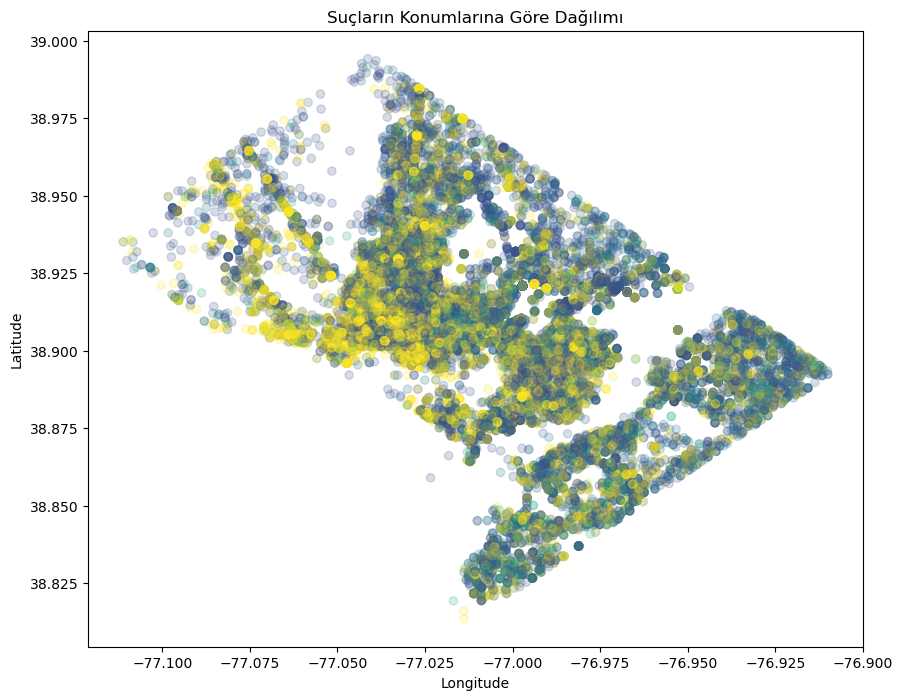

In [124]:
# Suçların harita üzerindeki dağılımını görselleştirme
plt.figure(figsize=(10, 8))
plt.scatter(df['LONGITUDE'], df['LATITUDE'], alpha=0.2, c=df['OFFENSE'].apply(lambda x: hash(x) % 10), cmap='viridis')
plt.title("Suçların Konumlarına Göre Dağılımı")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


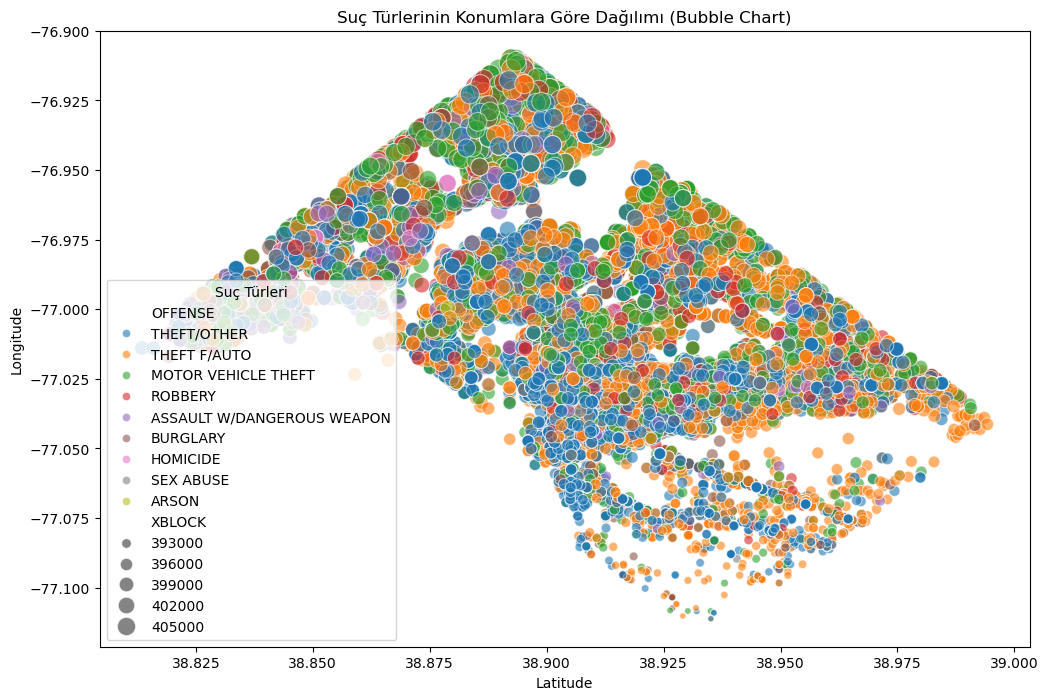

In [126]:
# Suç türlerinin dağılımını balon grafikle gösterme
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x="LATITUDE", y="LONGITUDE", hue="OFFENSE", size="XBLOCK", sizes=(20, 200), alpha=0.6)
plt.title("Suç Türlerinin Konumlara Göre Dağılımı (Bubble Chart)")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.legend(title="Suç Türleri")
plt.show()


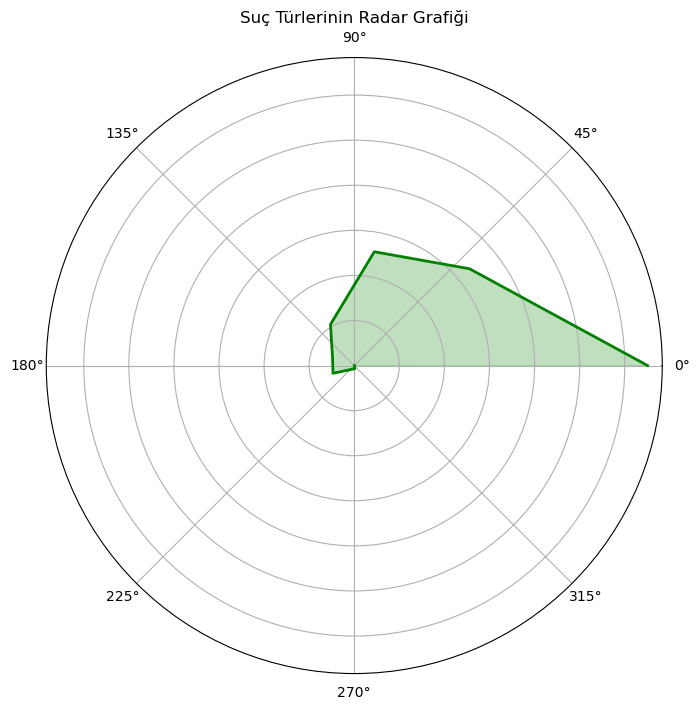

In [130]:
import numpy as np
import matplotlib.pyplot as plt

# İlçeler ve suç türleri için radar grafiği
labels = ['ARSON', 'ASSAULT W/DANGEROUS WEAPON', 'BURGLARY', 'HOMICIDE', 'MOTOR VEHICLE THEFT', 'ROBBERY', 'SEX ABUSE', 'THEFT F/AUTO', 'THEFT/OTHER']
values = df['OFFENSE'].value_counts().values
categories = list(df['DISTRICT'].unique())

# Radar grafiği için hazırlık
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()

# Grafik çizme
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, values, color='green', alpha=0.25)
ax.plot(angles, values, color='green', linewidth=2)
ax.set_yticklabels([])

plt.title("Suç Türlerinin Radar Grafiği")
plt.show()


In [145]:
import folium
from folium.plugins import HeatMap

# Verinin LATITUDE ve LONGITUDE kolonlarını kullanarak bir harita oluşturun
crime_map = folium.Map(location=[df['LATITUDE'].mean(), df['LONGITUDE'].mean()], zoom_start=12)
heat_data = [[row['LATITUDE'], row['LONGITUDE']] for index, row in df.iterrows()]

HeatMap(heat_data).add_to(crime_map)
crime_map.save("crime_heatmap.html")



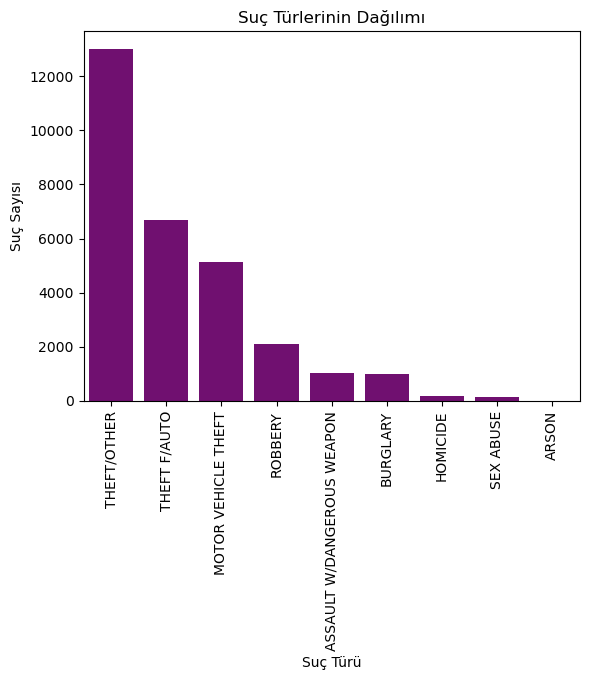

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

offense_counts = df['OFFENSE'].value_counts()

# 'palette' parametresini 'hue' parametresi olmadan kullanmamak için seaborn'un yeni sürümüne uygun kullanım
sns.barplot(x=offense_counts.index, y=offense_counts.values, color='purple')  # 'viridis' yerine sabit renk kullanabiliriz

plt.title("Suç Türlerinin Dağılımı")
plt.xlabel("Suç Türü")
plt.ylabel("Suç Sayısı")
plt.xticks(rotation=90)
plt.show()



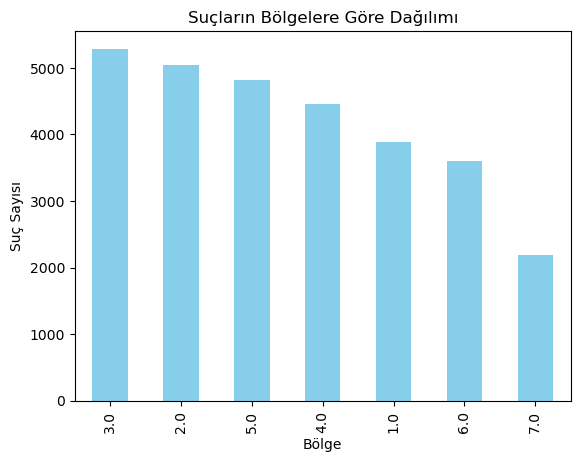

In [149]:
# Bölgelere göre suç sayılarının dağılımı
district_counts = df['DISTRICT'].value_counts()
district_counts.plot(kind='bar', color='skyblue')
plt.title("Suçların Bölgelere Göre Dağılımı")
plt.xlabel("Bölge")
plt.ylabel("Suç Sayısı")
plt.xticks(rotation=90)
plt.show()


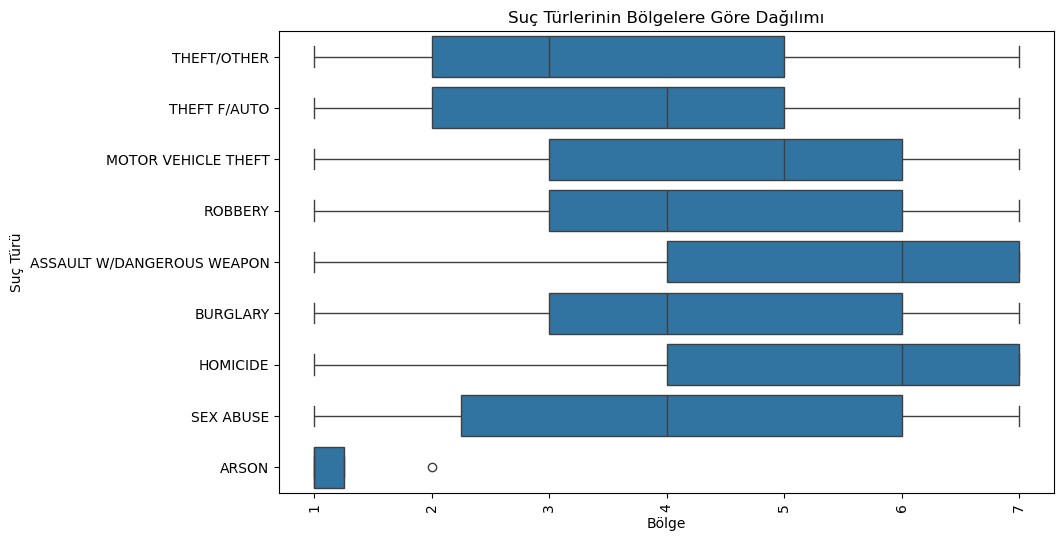

In [153]:
plt.figure(figsize=(10,6))
sns.boxplot(x='DISTRICT', y='OFFENSE', data=df)
plt.title('Suç Türlerinin Bölgelere Göre Dağılımı')
plt.xlabel('Bölge')
plt.ylabel('Suç Türü')
plt.xticks(rotation=90)
plt.show()

